In [1]:
# ============================================================
# 01. Configuração — Composição Temporal de NDVI
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray


# Diretório raiz do projeto
projeto = Path(
    r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
)

# Diretório dos produtos NDVI
pasta_ndvi = (
    projeto
    / "data"
    / "processed"
    / "indices"
    / "ndvi"
)

# Produto final
saida = pasta_ndvi / "ndvi_mediana_2020.tif"


print("=" * 60)
print("COMPOSIÇÃO TEMPORAL DE NDVI")
print("=" * 60)

print(f"\nProjeto:")
print(projeto)

print(f"\nPasta NDVI:")
print(pasta_ndvi)

COMPOSIÇÃO TEMPORAL DE NDVI

Projeto:
C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao

Pasta NDVI:
C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\ndvi


In [2]:
# ============================================================
# 02. Verificar arquivos NDVI
# ============================================================

arquivos = sorted(
    [
        arquivo
        for arquivo in pasta_ndvi.glob("ndvi_2020*.tif")
    ]
)

print(f"✓ {len(arquivos)} arquivos NDVI encontrados:\n")

for arquivo in arquivos:
    print(f"• {arquivo.name}")

✓ 12 arquivos NDVI encontrados:

• ndvi_20200115.tif
• ndvi_20200214.tif
• ndvi_20200325.tif
• ndvi_20200404.tif
• ndvi_20200519.tif
• ndvi_20200613.tif
• ndvi_20200723.tif
• ndvi_20200827.tif
• ndvi_20200926.tif
• ndvi_20201001.tif
• ndvi_20201125.tif
• ndvi_20201230.tif


In [3]:
# ============================================================
# 03. Carregar e alinhar os rasters NDVI
# ============================================================

rasters = []

# ------------------------------------------------------------
# 1. Abrir o primeiro raster como referência espacial
# ------------------------------------------------------------

arquivo_referencia = arquivos[0]

referencia = rioxarray.open_rasterio(
    arquivo_referencia,
    masked=True
).squeeze(drop=True)

if referencia.rio.crs is None:
    raise ValueError(
        f"Raster de referência sem CRS:\n"
        f"{arquivo_referencia.name}"
    )

print("Raster de referência:")
print(f"  Arquivo: {arquivo_referencia.name}")
print(f"  CRS: {referencia.rio.crs}")
print(f"  Resolução: {referencia.rio.resolution()}")
print(
    f"  Dimensões: "
    f"{referencia.rio.width} × {referencia.rio.height}"
)


# ------------------------------------------------------------
# 2. Carregar cada imagem e alinhar à referência
# ------------------------------------------------------------

for arquivo in arquivos:

    # --------------------------------------------------------
    # Extrair data
    # Exemplo:
    # ndvi_20220114.tif
    # --------------------------------------------------------

    data_str = arquivo.stem[-8:]

    data = pd.to_datetime(
        data_str,
        format="%Y%m%d"
    )

    # --------------------------------------------------------
    # Abrir raster
    # --------------------------------------------------------

    raster = rioxarray.open_rasterio(
        arquivo,
        masked=True
    ).squeeze(drop=True)

    # --------------------------------------------------------
    # Verificar CRS
    # --------------------------------------------------------

    if raster.rio.crs is None:
        raise ValueError(
            f"Raster sem CRS definido:\n{arquivo.name}"
        )

    # --------------------------------------------------------
    # Alinhar espacialmente à referência
    # --------------------------------------------------------

    raster_alinhado = raster.rio.reproject_match(
        referencia
    )

    # --------------------------------------------------------
    # Adicionar dimensão temporal
    # --------------------------------------------------------

    raster_alinhado = raster_alinhado.expand_dims(
        time=[data]
    )

    rasters.append(raster_alinhado)

    print(
        f"✓ {data.strftime('%d/%m/%Y')} "
        f"→ alinhado"
    )


# ============================================================
# 3. Criar cubo temporal
# ============================================================

cubo = xr.concat(
    rasters,
    dim="time",
    join="exact"
)

cubo = cubo.sortby("time")


# ============================================================
# 4. Resumo
# ============================================================

print("\n" + "=" * 60)
print("CUBO TEMPORAL — NDVI")
print("=" * 60)

print(f"Imagens:    {cubo.sizes['time']}")
print(f"Linhas:     {cubo.sizes['y']}")
print(f"Colunas:    {cubo.sizes['x']}")
print(f"CRS:        {cubo.rio.crs}")
print(f"Resolução:  {cubo.rio.resolution()}")

print(
    f"\nPeríodo: "
    f"{pd.to_datetime(cubo.time.values[0]).strftime('%d/%m/%Y')}"
    f" → "
    f"{pd.to_datetime(cubo.time.values[-1]).strftime('%d/%m/%Y')}"
)

Raster de referência:
  Arquivo: ndvi_20200115.tif
  CRS: EPSG:32722
  Resolução: (10.0, -10.0)
  Dimensões: 140 × 222
✓ 15/01/2020 → alinhado
✓ 14/02/2020 → alinhado
✓ 25/03/2020 → alinhado
✓ 04/04/2020 → alinhado
✓ 19/05/2020 → alinhado
✓ 13/06/2020 → alinhado
✓ 23/07/2020 → alinhado
✓ 27/08/2020 → alinhado
✓ 26/09/2020 → alinhado
✓ 01/10/2020 → alinhado
✓ 25/11/2020 → alinhado
✓ 30/12/2020 → alinhado

CUBO TEMPORAL — NDVI
Imagens:    12
Linhas:     222
Colunas:    140
CRS:        EPSG:32722
Resolução:  (10.0, -10.0)

Período: 15/01/2020 → 30/12/2020


In [4]:
# ============================================================
# 04. Composição temporal por mediana
# ============================================================

print("Calculando mediana temporal...")

ndvi_mediana = cubo.median(
    dim="time",
    skipna=True
)

print("✓ Mediana temporal calculada")

print("\nInformações do produto:")
print(f"  Dimensões: {ndvi_mediana.sizes}")
print(f"  CRS: {ndvi_mediana.rio.crs}")
print(f"  Resolução: {ndvi_mediana.rio.resolution()}")

Calculando mediana temporal...
✓ Mediana temporal calculada

Informações do produto:
  Dimensões: Frozen({'y': 222, 'x': 140})
  CRS: EPSG:32722
  Resolução: (10.0, -10.0)


In [5]:
# ============================================================
# 05. Estatísticas da composição temporal
# ============================================================

print("=" * 60)
print("ESTATÍSTICAS — NDVI MEDIANA")
print("=" * 60)

ndvi_min = ndvi_mediana.min(skipna=True).item()
ndvi_max = ndvi_mediana.max(skipna=True).item()
ndvi_media = ndvi_mediana.mean(skipna=True).item()
ndvi_mediana_valor = ndvi_mediana.median(skipna=True).item()

print(f"\nNDVI mínimo:       {ndvi_min:.4f}")
print(f"NDVI máximo:       {ndvi_max:.4f}")
print(f"NDVI médio:        {ndvi_media:.4f}")
print(f"Mediana do NDVI:   {ndvi_mediana_valor:.4f}")

ESTATÍSTICAS — NDVI MEDIANA

NDVI mínimo:       0.1121
NDVI máximo:       0.8875
NDVI médio:        0.5425
Mediana do NDVI:   0.4946


In [6]:
# ============================================================
# 06. Salvar composição temporal de NDVI
# ============================================================

saida = pasta_ndvi / "ndvi_mediana_2020.tif"

ndvi_mediana.rio.to_raster(
    saida,
    dtype="float32",
    compress="DEFLATE",
    predictor=3,
    tiled=True,
    BIGTIFF="IF_SAFER"
)

print("✓ GeoTIFF salvo com sucesso!")
print(f"\nArquivo:")
print(saida)

✓ GeoTIFF salvo com sucesso!

Arquivo:
C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\ndvi\ndvi_mediana_2020.tif


In [7]:
# ============================================================
# 07. Validação do GeoTIFF final
# ============================================================

ndvi_final = rioxarray.open_rasterio(
    saida,
    masked=True
).squeeze(drop=True)

print("=" * 60)
print("VALIDAÇÃO — NDVI MEDIANA 2020")
print("=" * 60)

print(f"\nArquivo:")
print(saida)

print(f"\nCRS:")
print(ndvi_final.rio.crs)

print(f"\nResolução:")
print(ndvi_final.rio.resolution())

print(f"\nDimensões:")
print(f"  Linhas:  {ndvi_final.rio.height}")
print(f"  Colunas: {ndvi_final.rio.width}")

print(f"\nNDVI mínimo: {ndvi_final.min().item():.4f}")
print(f"NDVI máximo: {ndvi_final.max().item():.4f}")
print(f"NDVI médio:  {ndvi_final.mean().item():.4f}")

print("\n✓ Validação concluída")

VALIDAÇÃO — NDVI MEDIANA 2020

Arquivo:
C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\ndvi\ndvi_mediana_2020.tif

CRS:
EPSG:32722

Resolução:
(10.0, -10.0)

Dimensões:
  Linhas:  222
  Colunas: 140

NDVI mínimo: 0.1121
NDVI máximo: 0.8875
NDVI médio:  0.5425

✓ Validação concluída


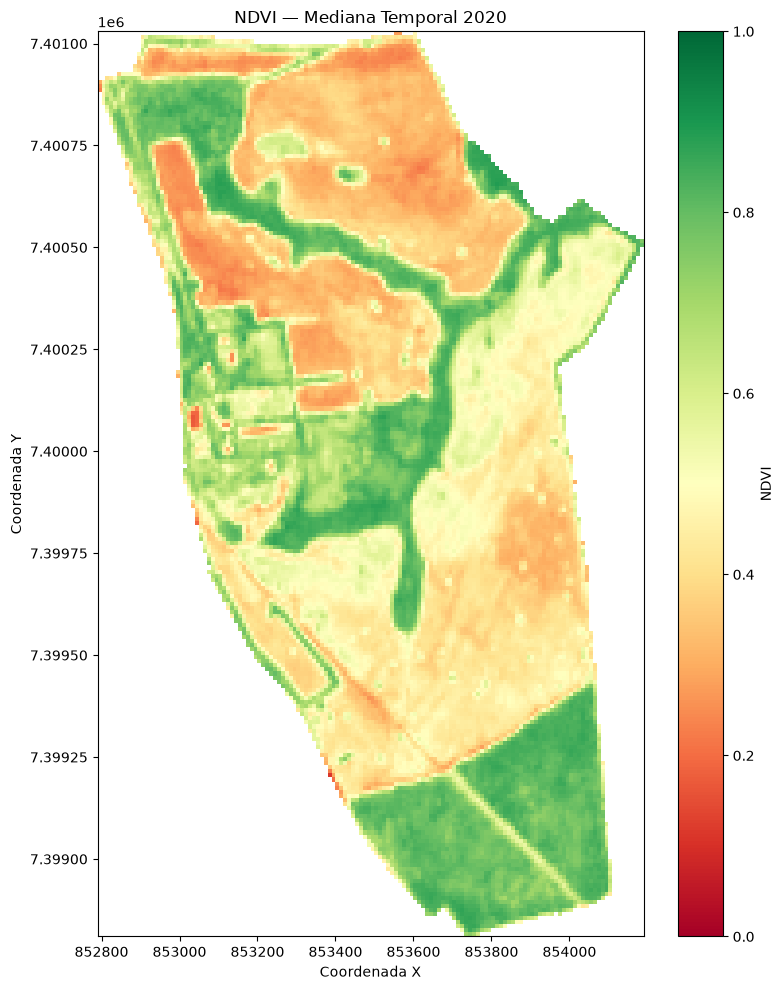

In [8]:
# ============================================================
# 08. Visualização — NDVI mediana 
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

ndvi_final.plot(
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    cbar_kwargs={
        "label": "NDVI"
    }
)

plt.title("NDVI — Mediana Temporal 2020")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 08. Metadados do GeoTIFF final
# ============================================================

ndvi = rioxarray.open_rasterio(
    saida,
    masked=True
)

print("=" * 60)
print("METADADOS — NDVI MEDIANA")
print("=" * 60)

print(f"\nResolução (x, y): {ndvi.rio.resolution()}")
print(f"CRS: {ndvi.rio.crs}")
print(f"Shape: {ndvi.shape}")
print(f"Bounds: {ndvi.rio.bounds()}")
print(f"Nodata: {ndvi.rio.nodata}")

METADADOS — NDVI MEDIANA

Resolução (x, y): (10.0, -10.0)
CRS: EPSG:32722
Shape: (1, 222, 140)
Bounds: (852790.0, 7398810.0, 854190.0, 7401030.0)
Nodata: None


In [10]:
# Verificar os dados antes do upsampling

ndvi_array = np.asarray(ndvi.squeeze().values)

print("Shape:", ndvi_array.shape)
print("Mínimo:", np.nanmin(ndvi_array))
print("Máximo:", np.nanmax(ndvi_array))
print("Quantidade de NaN:", np.isnan(ndvi_array).sum())
print("Total de pixels:", ndvi_array.size)

Shape: (222, 140)
Mínimo: 0.112133965
Máximo: 0.88747346
Quantidade de NaN: 11722
Total de pixels: 31080


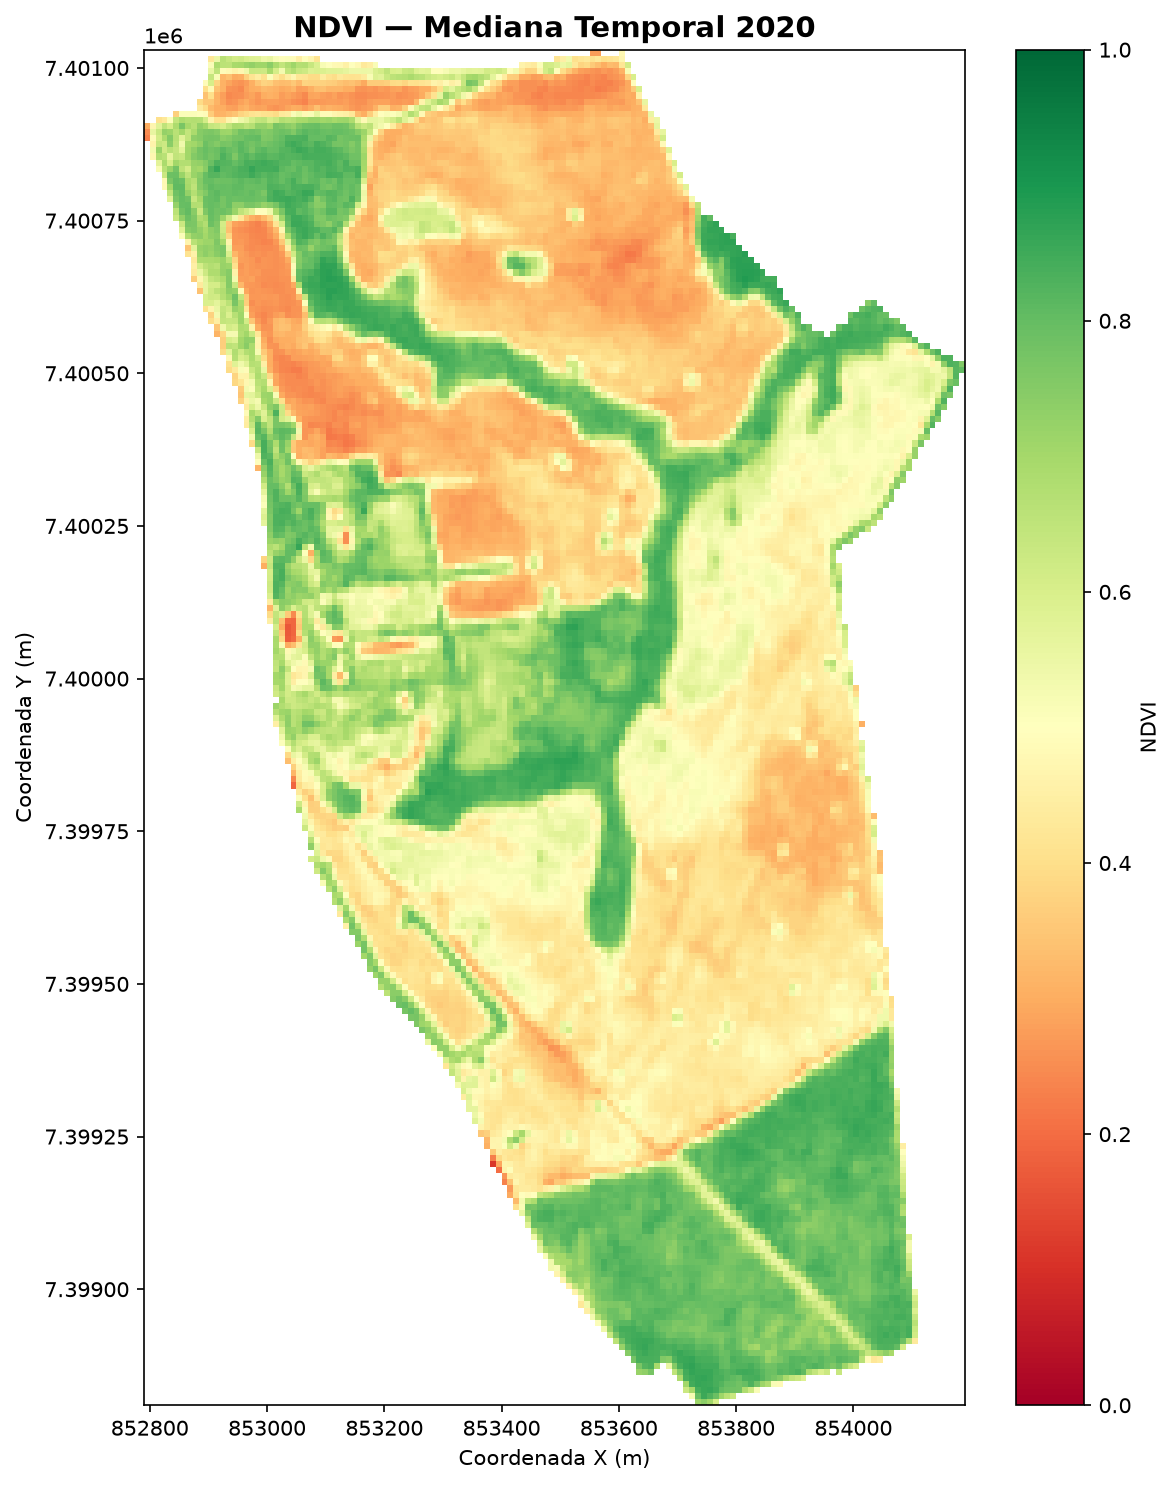

In [11]:
# ============================================================
# 08. Visualização do NDVI mediano — raster original
# ============================================================

import matplotlib.pyplot as plt
import rioxarray

ndvi = rioxarray.open_rasterio(
    saida,
    masked=True
).squeeze(drop=True)

fig, ax = plt.subplots(
    figsize=(8, 10),
    dpi=150
)

ndvi.plot.imshow(
    ax=ax,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    add_colorbar=True,
    cbar_kwargs={"label": "NDVI"}
)

ax.set_title(
    "NDVI — Mediana Temporal 2020",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Coordenada X (m)")
ax.set_ylabel("Coordenada Y (m)")

plt.tight_layout()
plt.show()

In [12]:
fig.savefig(
    pasta_ndvi / "ndvi_mediana_2020.png",
    dpi=300,
    bbox_inches="tight"
)